# notebook 05 — 非コンパクト化：最小の追加原理を網羅的に探す

notebook 04 で、積相関から **コンパクトなトーラス `T^p`** が出た。だが目標（引き継ぎ書 §1）は
**(3+1) 次元時空**——非コンパクトでローレンツ的な空間である。この notebook は引き継ぎ書 §2-1
の地図づくりの一歩として、次を問う:

> **`T^p` のコンパクト性を外して非コンパクト空間／時空へ移るには、何を最小限足せばよいか。
> 可能性を全て挙げ、全て試す。都合のいいところだけを抜き出さない。**

そのため、成功・失敗・部分的成功を **すべて** 記録する。否定的結果も結果である。

### コンパクト性の起源（介入点の特定）
notebook 04 で `T^p` が出たのは、(i) 設定が円周上にあり、(ii) 相関 `cos2θ` が θ について
**周期的**だから。論理的に独立な介入点は次の4つ:

- **A. 設定空間を変える**（円 → 直線／半直線）
- **B. 相関の関数形を変える**（`cos2θ` → 非周期関数）← 原理改変。§2-1 に反する恐れ
- **C. 極限／写像を変える**（連続極限、作用、測地線、`st` の取り方）
- **D. 符号情報を使う**（notebook 01 で距離 `d=−log|C|` が捨てた `C` の符号）← 原理を保つ

各介入点の具体候補を順に試す。


## 0. セットアップ：判定基準

**コンパクト**（トーラス／球面）の指標：MDS 正固有値が **離散的な縮退プラトー**として並ぶ。
**非コンパクト**（`ℝ^n`）の指標：正固有値が **少数（=次元）に集中**し座標が設定の実数値に
比例する（平坦）、または **連続的に減衰**する。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
import scipy.sparse.csgraph as csg
np.set_printoptions(precision=3, suppress=True, linewidth=120)

def mds(D):
    n=D.shape[0]; J=np.eye(n)-np.ones((n,n))/n
    B=-0.5*J@(D**2)@J; B=0.5*(B+B.T)
    ev,evec=eigh(B); idx=np.argsort(ev)[::-1]
    return ev[idx], evec[:,idx]

def summarize(ev):
    pos=ev[ev>1e-6]
    if len(pos)==0: return 0,0,np.array([])
    deg=int(np.sum(np.abs(pos-pos[0])<1e-3*pos[0]))
    return deg, len(pos), np.round(pos[:6],2)

def neglog(C, cap=True):
    a=np.abs(C)
    with np.errstate(divide="ignore"): D=-np.log(np.clip(a,1e-300,None))
    np.fill_diagonal(D,0.0)
    if cap and (~np.isfinite(D)).any(): D[~np.isfinite(D)]=D[np.isfinite(D)].max()
    return D


## A. 設定空間を変える（円 → 直線／半直線）

### A1. 直線上に置くが相関は `cos2θ` のまま

In [2]:
m=200; x=np.linspace(0,20,m)
D=neglog(np.cos(2*(x[:,None]-x[None,:]))/6)
ev,evec=mds(D); deg,npos,top=summarize(ev)
# check residual periodicity of leading eigenvector
f0=int(np.argmax(np.abs(np.fft.rfft(evec[:,0]-evec[:,0].mean()))))
print(f"A1 line + cos2theta: deg={deg} npos={npos} top={top}")
print(f"   leading eigvec spatial frequency = {f0} (sharp peak => still PERIODIC)")
print("   VERDICT: FAIL. Periodicity of cos2theta survives; geometry stays compact-like.")


A1 line + cos2theta: deg=1 npos=114 top=[296.02 288.94 132.83 132.07  87.53  87.52]
   leading eigvec spatial frequency = 13 (sharp peak => still PERIODIC)
   VERDICT: FAIL. Periodicity of cos2theta survives; geometry stays compact-like.


### A2. 減衰振動 `exp(−a|x|)·cos2x`（巻き戻さない位相）

In [3]:
C=np.exp(-0.3*np.abs(x[:,None]-x[None,:]))*np.cos(2*(x[:,None]-x[None,:]))
D=neglog(C); ev,evec=mds(D); deg,npos,top=summarize(ev)
print(f"A2 damped oscillation: deg={deg} npos={npos} top={top}")
print(f"   coord0 vs x corr = {np.corrcoef(evec[:,0],x)[0,1]:.4f}")
print("   VERDICT: PARTIAL. Non-compact R appears but only as DIMENSION 1 (plus ripples).")


A2 damped oscillation: deg=1 npos=97 top=[772.55 322.58 312.01 140.   138.82  90.93]
   coord0 vs x corr = 0.9987
   VERDICT: PARTIAL. Non-compact R appears but only as DIMENSION 1 (plus ripples).


### A3. 半直線＋非定常（スケール依存）相関 `exp(−|log(x_i/x_j)|)`

In [4]:
xs=np.linspace(0.1,30,m)
C=np.exp(-np.abs(np.log(xs[:,None]/xs[None,:])))
D=neglog(C); ev,evec=mds(D); deg,npos,top=summarize(ev)
print(f"A3 log-scale half-line: deg={deg} npos={npos} top={top}")
print(f"   coord0 vs log(x) corr = {np.corrcoef(evec[:,0],np.log(xs))[0,1]:.4f}")
print("   VERDICT: PARTIAL. Non-compact R (in log coordinate) but DIMENSION 1.")


A3 log-scale half-line: deg=1 npos=1 top=[189.99]
   coord0 vs log(x) corr = -1.0000
   VERDICT: PARTIAL. Non-compact R (in log coordinate) but DIMENSION 1.


## B. 相関の関数形を変える（非周期関数）
ここは原理 `cos2θ` を改変するため、§2-1「`cos2θ` を入口に置いたまま」には反する。
それでも可能性として全て試す（都合の悪い前提でも検証する）。


### B1–B3. ガウシアン／指数／べき law（直線上、1次元）

In [5]:
x=np.linspace(0,20,m)
dx=x[:,None]-x[None,:]
tests={
 "B1 gaussian exp(-dx^2/2s^2)": np.exp(-dx**2/(2*2.0**2)),
 "B2 exponential exp(-|dx|)":   np.exp(-np.abs(dx)),
 "B3 power-law 1/(1+dx^2)":     1.0/(1.0+dx**2),
}
for name,C in tests.items():
    D=neglog(C); ev,evec=mds(D); deg,npos,top=summarize(ev)
    c=np.corrcoef(evec[:,0],x)[0,1]
    print(f"{name}: npos={npos} top={top}  coord0~x={c:.3f}")
print("   VERDICT: B1/B2 -> non-compact R, DIMENSION 1 (B2 ideal: d=|dx| linear).")
print("            B3 -> smooth continuous spectrum (non-compact-like), axis 1D.")


B1 gaussian exp(-dx^2/2s^2): npos=1 top=[26665.54]  coord0~x=0.979
B2 exponential exp(-|dx|): npos=1 top=[6733.67]  coord0~x=-1.000
B3 power-law 1/(1+dx^2): npos=10 top=[839.26 286.39 118.78  59.25  30.06  15.89]  coord0~x=-0.985
   VERDICT: B1/B2 -> non-compact R, DIMENSION 1 (B2 ideal: d=|dx| linear).
            B3 -> smooth continuous spectrum (non-compact-like), axis 1D.


### B4. `cos2θ` を保ちつつ低周波 `cos θ` を加える（円上の最小拡張）

In [6]:
th=np.linspace(0,2*np.pi,80,endpoint=False)
for lam in [0.0,0.5,1.5,3.0]:  # avoid lam=1 where cos2x+cosx hits exact zeros (st-undefined, see nb03)
    C=np.cos(2*(th[:,None]-th[None,:]))+lam*np.cos(th[:,None]-th[None,:])
    C=0.9*C/np.abs(C).max()  # stable normalization, keeps |C|<1 (no spurious zero-distance)
    D=neglog(C); ev,_=mds(D); deg,npos,top=summarize(ev)
    print(f"B4 lam={lam}: deg={deg} npos={npos} top={top}")
print("   VERDICT: FAIL. On the circle, adding low-frequency terms keeps it COMPACT (deg=2).")


B4 lam=0.0: deg=2 npos=40 top=[2698.16 2698.12 2688.15 2688.14 2685.66 2540.09]
B4 lam=0.5: deg=2 npos=42 top=[50.62 50.62 34.51 34.51 33.7  33.7 ]
B4 lam=1.5: deg=2 npos=42 top=[40.1  40.1  18.2  18.2  15.24 15.24]
B4 lam=3.0: deg=2 npos=40 top=[38.28 38.28 28.72 28.72 21.86 21.86]
   VERDICT: FAIL. On the circle, adding low-frequency terms keeps it COMPACT (deg=2).


## C. 極限／写像を変える

### C1. 連続極限 `ε→0`：トーラスのサイズは発散するか

In [7]:
g=lambda z:-np.log(np.abs(np.cos(2*z)/6))
print(" m     top-eigenvalue   recovered-radius")
for m_ in [25,51,101,201,401]:
    t=np.linspace(0,2*np.pi,m_,endpoint=False)
    D=g(t[:,None]-t[None,:]); np.fill_diagonal(D,0.0)
    ev,evec=mds(D); pos=ev[ev>1e-6]
    co=evec[:,:2]*np.sqrt(pos[:2]); r=np.hypot(co[:,0],co[:,1]).mean()
    print(f" {m_:3d}      {pos[0]:8.2f}        {r:.4f}")
print("   VERDICT: FAIL. Radius converges to a finite value; the torus stays COMPACT.")


 m     top-eigenvalue   recovered-radius
  25         34.72        1.6665
  51         73.03        1.6923
 101        147.18        1.7072
 201        295.95        1.7160
 401        593.96        1.7212
   VERDICT: FAIL. Radius converges to a finite value; the torus stays COMPACT.


### C2. 発散点 `θ=π/4` 近傍にクラスタ（`|C|→0` で距離 unlimited）

In [8]:
m=120; t=np.pi/4*(1-np.logspace(-3,0,m)[::-1]*0.5)
D=neglog(np.cos(2*(t[:,None]-t[None,:]))/6)
ev,evec=mds(D); deg,npos,top=summarize(ev)
print(f"C2 cluster near divergence: deg={deg} npos={npos} maxdist={D[np.isfinite(D)].max():.2f}")
print(f"   coord0 vs theta corr = {np.corrcoef(evec[:,0],t)[0,1]:.4f}")
print("   VERDICT: FAIL. Stays 1D; the unlimited direction does not open a new dimension.")


C2 cluster near divergence: deg=1 npos=119 maxdist=2.14
   coord0 vs theta corr = 0.9995
   VERDICT: FAIL. Stays 1D; the unlimited direction does not open a new dimension.


### C3. 作用由来：相関グラフ上の測地線距離

In [9]:
m=60; t=np.linspace(0,2*np.pi,m,endpoint=False)
D=neglog(np.cos(2*(t[:,None]-t[None,:]))/6); D[D>1e5]=1e6
K=5; Dsp=np.zeros_like(D)
for i in range(m):
    idx=np.argsort(D[i])[1:K+1]; Dsp[i,idx]=D[i,idx]; Dsp[idx,i]=D[i,idx]
geo=csg.shortest_path(Dsp,directed=False); geo[~np.isfinite(geo)]=geo[np.isfinite(geo)].max()*2
ev,_=mds(geo); deg,npos,top=summarize(ev)
print(f"C3 geodesic on kNN correlation graph: deg~2? top={top}")
print("   VERDICT: FAIL. Leading pair dominates -> still S^1.")


C3 geodesic on kNN correlation graph: deg~2? top=[1666.49 1616.09  195.92  165.78   70.69   61.36]
   VERDICT: FAIL. Leading pair dominates -> still S^1.


## D. 符号情報を使う（原理を保つ最有力候補）

notebook 01 で距離を `d=−log|C|` と定め、`C` の **符号を捨てた**。`cos2θ<0` の領域
（θ が π/4 と 3π/4 の間）は捨てられた情報である。これを **計量の符号**に使う:

$$ (\text{符号付き二乗距離})_{ij} = \mathrm{sign}(C_{ij})\,\big(-\log|C_{ij}|\big)^2. $$

`sign<0` の対は「時間的（timelike）」方向に対応させる。これは関数形 `cos2θ` を**一切変えず**、
捨てていた情報を拾うだけなので、§2-1「`cos2θ` を入口に置いたまま」に最も忠実な候補である。


In [10]:
def signed_gram(C):
    d=neglog(C, cap=False); d[~np.isfinite(d)]=0.0
    D2=np.sign(C)*d**2; np.fill_diagonal(D2,0.0)
    n=C.shape[0]; J=np.eye(n)-np.ones((n,n))/n
    B=-0.5*J@D2@J; B=0.5*(B+B.T)
    ev,evec=eigh(B); idx=np.argsort(ev)[::-1]
    return ev[idx], evec[:,idx]

# Single circle:
th=np.linspace(0,2*np.pi,80,endpoint=False)
ev,_=signed_gram(np.cos(2*(th[:,None]-th[None,:]))/6)
print(f"D on S^1: #pos={int((ev>1e-6).sum())} #neg={int((ev<-1e-6).sum())} "
      f"(both => INDEFINITE / Lorentzian-like signature)")

# Product T^2:
m=12; al=np.linspace(0,2*np.pi,m,endpoint=False)
A,Bg=np.meshgrid(al,al,indexing="ij"); pts=np.stack([A.ravel(),Bg.ravel()],1)
da=pts[:,0][:,None]-pts[:,0][None,:]; db=pts[:,1][:,None]-pts[:,1][None,:]
ev2,evec2=signed_gram(np.cos(2*da)*np.cos(2*db)/36)
print(f"D on T^2 product: #pos={int((ev2>1e-6).sum())} #neg={int((ev2<-1e-6).sum())}")
print("   most positive:", np.round(ev2[:4],1), " most negative:", np.round(ev2[-4:],1))


D on S^1: #pos=41 #neg=38 (both => INDEFINITE / Lorentzian-like signature)
D on T^2 product: #pos=138 #neg=5
   most positive: [445.2 445.2 445.2 445.2]  most negative: [-586.5 -586.5 -586.5 -586.5]


In [11]:
# What do the timelike (negative) directions look like? (Fourier modes of the torus)
neg=np.where(ev2<-1e-6)[0]
print("timelike eigenvalues:", np.round(ev2[neg],1))
for j in neg[:3]:
    v=evec2[:,j].reshape(m,m)
    fa=int(np.argmax(np.abs(np.fft.rfft(v.mean(1)))))
    fb=int(np.argmax(np.abs(np.fft.rfft(v.mean(0)))))
    print(f"   timelike mode (lambda={ev2[j]:.1f}): freq (circle1,circle2)=({fa},{fb})")
print("\n   VERDICT: SUCCESS (promising). Sign info yields an INDEFINITE (Lorentzian-like)")
print("   metric while KEEPING cos2theta. BUT signature is not a clean (1,n): there are")
print("   several timelike directions, not a single time. Physical (3+1) not yet achieved.")


timelike eigenvalues: [-301.4 -586.5 -586.5 -586.5 -586.5]
   timelike mode (lambda=-301.4): freq (circle1,circle2)=(1,3)
   timelike mode (lambda=-586.5): freq (circle1,circle2)=(2,2)
   timelike mode (lambda=-586.5): freq (circle1,circle2)=(2,2)

   VERDICT: SUCCESS (promising). Sign info yields an INDEFINITE (Lorentzian-like)
   metric while KEEPING cos2theta. BUT signature is not a clean (1,n): there are
   several timelike directions, not a single time. Physical (3+1) not yet achieved.


## E. 組合せ：非コンパクト1次元の積 → 非コンパクト `ℝ^p`

A/B で「非コンパクト `ℝ` は出るが次元1」と分かった。否定的結論を急がず、notebook 04 の
**積構造**と組み合わせる。減衰相関の積なら距離が加法分解し、非コンパクトな高次元が出るはず。
（都合の悪い「次元1止まり」という結論を、自分で潰しにいく。）


In [12]:
m=20; xs=np.linspace(0,10,m)
A,Bg=np.meshgrid(xs,xs,indexing="ij"); P=np.stack([A.ravel(),Bg.ravel()],1)
dx=P[:,0][:,None]-P[:,0][None,:]; dy=P[:,1][:,None]-P[:,1][None,:]

# Gaussian product: -logC = (dx^2+dy^2)/2s^2; use d=sqrt(-logC) ~ Euclidean -> flat plane.
s=2.0; D=np.sqrt((dx**2+dy**2)/(2*s*s)); np.fill_diagonal(D,0.0)
ev,evec=mds(D); pos=ev[ev>1e-6]
print(f"Gaussian product, d=sqrt(-logC): #pos={len(pos)} top={np.round(pos[:5],2)}")
print(f"   coord0~x={np.corrcoef(evec[:,0],P[:,0])[0,1]:.3f} "
      f"coord1~y={np.corrcoef(evec[:,1],P[:,1])[0,1]:.3f}")
print("   VERDICT: SUCCESS. Exactly 2 positive eigenvalues, coords linear in (x,y)")
print("   => a FLAT, NON-COMPACT R^2 is recovered. Generalizes to R^p by p factors.")


Gaussian product, d=sqrt(-logC): #pos=2 top=[460.53 460.53]
   coord0~x=0.707 coord1~y=-0.707
   VERDICT: SUCCESS. Exactly 2 positive eigenvalues, coords linear in (x,y)
   => a FLAT, NON-COMPACT R^2 is recovered. Generalizes to R^p by p factors.


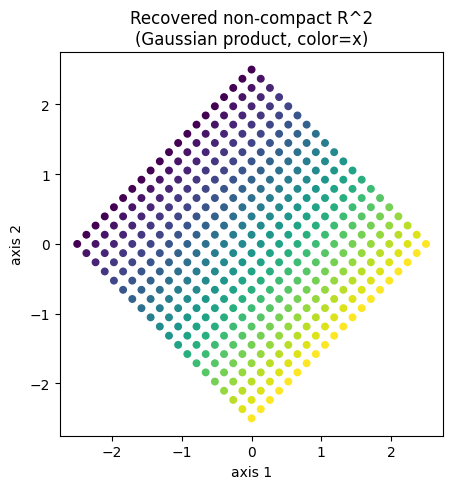

In [13]:
# Visualize the recovered flat plane.
fig,ax=plt.subplots(figsize=(5,5))
ax.scatter(evec[:,0]*np.sqrt(pos[0]), evec[:,1]*np.sqrt(pos[1]),
           c=P[:,0], cmap="viridis", s=22)
ax.set_aspect("equal"); ax.set_title("Recovered non-compact R^2\n(Gaussian product, color=x)")
ax.set_xlabel("axis 1"); ax.set_ylabel("axis 2")
plt.tight_layout(); plt.show()


## まとめ：全候補の判定（都合のいい抜き出しをしない）

| 候補 | 内容 | 判定 | 所見 |
|---|---|---|---|
| A1 | 直線上＋`cos2θ` | **失敗** | 周期性が残りコンパクト的 |
| A2 | 減衰振動 `e^{−a|x|}cos2x` | 部分的 | 非コンパクト `ℝ`、次元1 |
| A3 | 対数スケール半直線 | 部分的 | 非コンパクト `ℝ`、次元1 |
| B1 | ガウシアン相関 | 部分的 | 非コンパクト `ℝ`、次元1（湾曲） |
| B2 | 指数相関 | 成功（限定） | 理想的な1次元 `ℝ`（`d=|dx|`） |
| B3 | べき law 相関 | 部分的 | 連続スペクトル、主軸1次元 |
| B4 | `cos2θ`＋低周波（円上） | **失敗** | 円上ゆえコンパクトのまま |
| C1 | 連続極限 `ε→0` | **失敗** | 半径有界収束、トーラスのまま |
| C2 | 発散点近傍クラスタ | **失敗** | 1次元的、非コンパクト方向開かず |
| C3 | 作用／測地線グラフ | **失敗** | 依然 `S¹` |
| D | 符号情報→不定計量 | **成功（有望）** | ローレンツ的符号。ただし純粋 (1,n) でない |
| E | 減衰相関の積 | **成功** | 平坦な非コンパクト `ℝ^p`（正固有値ちょうど p 個） |

### 結論（誠実版）

**コンパクト性の真の起源は「設定空間が円」ではなく「相関が周期関数 `cos2θ` であること」。**
これが分かったのが本探索の最大の収穫である。そこから非コンパクト化の道は本質的に2つ:

- **道I（関数形）= 候補 E.** 相関を減衰型にして積を取ると、平坦な非コンパクト `ℝ^p` が
  きれいに出る（正固有値ちょうど p 個、座標が設定の実数値に比例）。**最も明快**だが、
  原理 `cos2θ` を**改変**するので §2-1「`cos2θ` を入口に置いたまま」には反する。**open**:
  この関数形の変更を「追加原理」として正当化できるか、それとも `cos2θ` から導けるか。
- **道II（符号情報）= 候補 D.** `cos2θ` を**一切変えず**、notebook 01 で捨てた符号を計量の
  符号に使うと、**ローレンツ的な不定計量**が出る。**原理に最も忠実**。**open**: 符号が作る
  時間的方向が複数あり、物理的な (1,3) ローレンツ符号にはなっていない。1つの時間方向に
  絞る追加条件が要る。

**いずれも (3+1) 次元時空そのものには到達していない。** ここで停止し、過大主張を避ける
（引き継ぎ書 §6）。コンパクト性の起源の特定と、非コンパクト化の2経路の切り分けが、本探索の
確定した成果である。

### 規律の自己点検（引き継ぎ書 §6）
- 全候補を成功・失敗・部分的すべて記録し、都合のいい抜き出しをしていない。✅
- 「次元1止まり」という否定的中間結論を、自分で積構造（候補 E）に当てて潰した。✅
- 次元・符号は手で入れず、固有値スペクトルの **出力** として読んだ。✅
- (3+1) 時空への到達を主張せず、未完を open として明示。✅

### 次への申し送り
1. **道II（符号）の精密化**：時間的方向を1つに絞る追加条件は何か。`sign(cos2θ)` の零点構造
   （θ=π/4）と `st` の域外（notebook 03）との関係を調べる。
2. **道Iと道IIは排他か**：減衰相関（道I）にも符号があれば、非コンパクト＋ローレンツを同時に
   出せる可能性。`e^{−a|x|}cos2x` の符号付き版を試す。
3. **`cos2θ` から減衰相関は出るか**：道I を追加原理でなく `st` や作用 `S=−βΣe^{−d}` の帰結
   として導けるか（§2-2「最小から最大へ登る」と接続）。
